In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Paths from previous milestones
FEATURE_SENTIMENT_FILE = "outputs_M2/M2_Feature_Sentiment.csv"
FEATURE_REQUEST_FILE = "outputs_M2/M2_Feature_Request_Counts.csv"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# STEP 1: LOAD M2 AGGREGATES

feat_sent = pd.read_csv(FEATURE_SENTIMENT_FILE)
feat_req = pd.read_csv(FEATURE_REQUEST_FILE)

print("Feature sentiment (M2):")
display(feat_sent)

print("Feature request counts (M2):")
display(feat_req)


Feature sentiment (M2):


,Feature_Category,Review_Count,Avg_Sentiment_Polarity,Positive_%,Neutral_%,Negative_%,Net_Sentiment_%
0,Calorie_Nutrition,585,0.315637,89.914530,4.102564,5.982906,83.931624
1,UI_UX,244,0.299173,92.213115,0.000000,7.786885,84.426230
2,Workout_Tracking,215,0.322698,94.883721,0.000000,5.116279,89.767442
3,Customer_Support,146,0.303235,97.260274,0.000000,2.739726,94.520548
4,Premium_Subscription,140,0.314617,85.714286,0.000000,14.285714,71.428571
5,Bug_Technical,124,0.179502,67.741935,9.677419,22.580645,45.161290
6,Sync_Integration,112,0.249855,75.892857,13.392857,10.714286,65.178571
7,Offline_Mode,33,0.057031,51.515152,6.060606,42.424242,9.090909


Feature request counts (M2):


,Request_Category,Count
0,Other,306
1,Wearable_integration,21
2,Social_features,11
3,Meal_planning,6
4,Water_intake_tracking,6
5,Offline_mode,2


In [3]:
# STEP 2: CONSOLIDATED FEATURE LIST

consolidated_features = [
    "Offline mode for workouts",
    "Apple Watch / Wearable integration",
    "Rest timer between sets",
    "Dark mode UI themes",
    "Custom workout builder",
    "Social / community features",
    "Progress photo tracking",
    "Advanced nutrition / meal planning",
    "Water intake tracker",
    "Export workout data",
    "Video exercise demonstrations",
    "Voice-guided workouts",
]

feat_df = pd.DataFrame({"Feature": consolidated_features})
display(feat_df)


,Feature
0,Offline mode for workouts
1,Apple Watch / Wearable integration
2,Rest timer between sets
3,Dark mode UI themes
4,Custom workout builder
5,Social / community features
6,Progress photo tracking
7,Advanced nutrition / meal planning
8,Water intake tracker
9,Export workout data


In [4]:
# STEP 3: LINK TO M2 MENTIONS & SENTIMENT (HEURISTIC)

feature_to_m2_cat = {
    "Offline mode for workouts": "Offline_Mode",
    "Apple Watch / Wearable integration": "Sync_Integration",
    "Rest timer between sets": "Workout_Tracking",
    "Dark mode UI themes": "UI_UX",
    "Custom workout builder": "Workout_Tracking",
    "Social / community features": "Social_features",   # from REQUEST_CATEGORIES in M2
    "Progress photo tracking": "Progress_photos",
    "Advanced nutrition / meal planning": "Calorie_Nutrition",
    "Water intake tracker": "Water_intake_tracking",
    "Export workout data": "Export_data",
    "Video exercise demonstrations": "Workout_Tracking",
    "Voice-guided workouts": "Workout_Tracking",
}

# Helper to pull M2 feature sentiment (by Feature_Category) where available
feat_sent = feat_sent.rename(columns={"Feature_Category": "M2_Feature_Category"})

def get_m2_feature_sentiment(m2_cat):
    row = feat_sent[feat_sent["M2_Feature_Category"] == m2_cat]
    if row.empty:
        return np.nan
    return float(row.iloc[0]["Avg_Sentiment_Polarity"])

# Helper to pull M2 request frequency for a request category
feat_req = feat_req.rename(columns={"Request_Category": "M2_Request_Category"})

def get_m2_request_count(req_cat):
    row = feat_req[feat_req["M2_Request_Category"] == req_cat]
    if row.empty:
        return 0
    return int(row.iloc[0]["Count"])

# Build table with:
# - M2 category used for sentiment
# - M2 request category used for mentions
m2_cat_for_sentiment = []
m2_cat_for_requests = []
m2_sentiment = []
m2_req_count = []

for f in consolidated_features:
    m2_cat = feature_to_m2_cat.get(f)
    # sentiment:
    if m2_cat in ["Workout_Tracking", "Calorie_Nutrition", "UI_UX",
                  "Sync_Integration", "Offline_Mode", "Premium_Subscription",
                  "Bug_Technical", "Customer_Support"]:
        sent_cat = m2_cat
        req_cat = None  # mentions mostly come via request categories below
    else:
        # M2 request categories: Social_features, Progress_photos, Meal_planning, Water_intake_tracking, Export_data
        sent_cat = None  # some have no direct sentiment in feat_sent
        req_cat = m2_cat

    m2_cat_for_sentiment.append(sent_cat)
    m2_cat_for_requests.append(req_cat)

    # pick sentiment
    if sent_cat is not None:
        m2_sentiment.append(get_m2_feature_sentiment(sent_cat))
    else:
        m2_sentiment.append(np.nan)

    # pick request counts
    if req_cat is not None:
        m2_req_count.append(get_m2_request_count(req_cat))
    else:
        # For ones mapped to feature categories, approximate mentions by using that category's Review_Count
        row = feat_sent[feat_sent["M2_Feature_Category"] == m2_cat]
        if row.empty:
            m2_req_count.append(0)
        else:
            m2_req_count.append(int(row.iloc[0]["Review_Count"]))

feat_df["M2_Sentiment_Category"] = m2_cat_for_sentiment
feat_df["M2_Request_Category"] = m2_cat_for_requests
feat_df["M2_Avg_Sentiment_Polarity"] = m2_sentiment
feat_df["M2_Mention_Count"] = m2_req_count

print("Consolidated features linked to M2 signals:")
display(feat_df)


Consolidated features linked to M2 signals:


,Feature,M2_Sentiment_Category,M2_Request_Category,M2_Avg_Sentiment_Polarity,M2_Mention_Count
0,Offline mode for workouts,Offline_Mode,None,0.057031,33
1,Apple Watch / Wearable integration,Sync_Integration,None,0.249855,112
2,Rest timer between sets,Workout_Tracking,None,0.322698,215
3,Dark mode UI themes,UI_UX,None,0.299173,244
4,Custom workout builder,Workout_Tracking,None,0.322698,215
5,Social / community features,None,Social_features,NaN,11
6,Progress photo tracking,None,Progress_photos,NaN,0
7,Advanced nutrition / meal planning,Calorie_Nutrition,None,0.315637,585
8,Water intake tracker,None,Water_intake_tracking,NaN,6
9,Export workout data,None,Export_data,NaN,0


In [5]:
# STEP 4: ESTIMATE RICE PARAMETERS (REACH etc.)

# We need: Reach, Impact, Confidence, Effort

# ------- Reach estimation -------
# Project spec: use review mention share as proxy for Reach.
total_reviews = 50000  # assumed total users from brief (50K MAU)

# Use mention proportion among all features as simple scaling.
total_mentions_all_features = feat_df["M2_Mention_Count"].sum()
if total_mentions_all_features == 0:
    total_mentions_all_features = 1  # avoid div-by-zero

feat_df["Mention_Share"] = feat_df["M2_Mention_Count"] / total_mentions_all_features

# Assume quarter = 1 quarter, Reach = share * 20,000 users per quarter (from spec ranges)
MAX_REACH_PER_QUARTER = 20000
feat_df["Reach_per_quarter"] = (feat_df["Mention_Share"] * MAX_REACH_PER_QUARTER).round(0)

# ------- Impact estimation -------
# Map average sentiment polarity to Impact levels.[file:8]
# Rules (you can tweak thresholds slightly in report text):
#   Avg polarity <= -0.3  -> Massive (3.0)
#   -0.3 < polarity <= -0.1 -> High (2.0)
#   -0.1 < polarity < 0.1 -> Medium (1.0)
#   0.1 <= polarity < 0.3 -> Low (0.5)
#   >= 0.3 -> Minimal (0.25) (they are already loved; new feature is incremental)
def polarity_to_impact(p):
    if pd.isna(p):
        # no sentiment -> assume Medium impact
        return 1.0
    if p <= -0.3:
        return 3.0
    elif p <= -0.1:
        return 2.0
    elif p < 0.1:
        return 1.0
    elif p < 0.3:
        return 0.5
    else:
        return 0.25

feat_df["Impact"] = feat_df["M2_Avg_Sentiment_Polarity"].apply(polarity_to_impact)

# Offline mode is usually severe pain point -> Massive
feat_df.loc[feat_df["Feature"] == "Offline mode for workouts", "Impact"] = 3.0
# Rest timer often high pain -> High
feat_df.loc[feat_df["Feature"] == "Rest timer between sets", "Impact"] = 2.0
# Dark mode nice-to-have -> Medium
feat_df.loc[feat_df["Feature"] == "Dark mode UI themes", "Impact"] = 1.0

# ------- Confidence estimation -------
# Based on data richness (mentions and sentiment availability)
def estimate_confidence(row):
    has_sent = not pd.isna(row["M2_Avg_Sentiment_Polarity"])
    mentions = row["M2_Mention_Count"]
    if has_sent and mentions >= 50:
        return 1.0   # 100%
    elif has_sent and mentions >= 10:
        return 0.8   # 80%
    else:
        return 0.5   # 50%

feat_df["Confidence"] = feat_df.apply(estimate_confidence, axis=1)

# ------- Effort estimation (person-months) -------
# We encode simple assumptions aligned with spec examples
def estimate_effort(feature_name):
    f = feature_name.lower()
    if "offline" in f:
        return 3.0  # large
    if "wearable" in f or "apple watch" in f:
        return 4.0  # very large
    if "rest timer" in f:
        return 1.0  # small
    if "dark mode" in f:
        return 1.0  # small
    if "custom workout" in f:
        return 3.0  # large
    if "social" in f or "community" in f:
        return 3.0
    if "progress photo" in f:
        return 2.0
    if "nutrition" in f or "meal" in f:
        return 3.0
    if "water intake" in f:
        return 1.0
    if "export workout" in f or "export data" in f:
        return 1.0
    if "video exercise" in f:
        return 2.0
    if "voice-guided" in f or "voice guided" in f:
        return 2.0
    return 2.0  # default

feat_df["Effort_person_months"] = feat_df["Feature"].apply(estimate_effort)

print("Features with estimated RICE inputs:")
display(feat_df[[
    "Feature", "M2_Avg_Sentiment_Polarity", "M2_Mention_Count",
    "Reach_per_quarter", "Impact", "Confidence", "Effort_person_months"
]])


Features with estimated RICE inputs:


,Feature,M2_Avg_Sentiment_Polarity,M2_Mention_Count,Reach_per_quarter,Impact,Confidence,Effort_person_months
0,Offline mode for workouts,0.057031,33,357.0,3.00,0.8,3.0
1,Apple Watch / Wearable integration,0.249855,112,1210.0,0.50,1.0,4.0
2,Rest timer between sets,0.322698,215,2323.0,2.00,1.0,1.0
3,Dark mode UI themes,0.299173,244,2636.0,1.00,1.0,1.0
4,Custom workout builder,0.322698,215,2323.0,0.25,1.0,3.0
5,Social / community features,NaN,11,119.0,1.00,0.5,3.0
6,Progress photo tracking,NaN,0,0.0,1.00,0.5,2.0
7,Advanced nutrition / meal planning,0.315637,585,6321.0,0.25,1.0,3.0
8,Water intake tracker,NaN,6,65.0,1.00,0.5,1.0
9,Export workout data,NaN,0,0.0,1.00,0.5,1.0


In [6]:
# ===============================
# STEP 5: CALCULATE RICE SCORES
# ===============================

# RICE = (Reach * Impact * Confidence) / Effort
feat_df["RICE_Score"] = (
    feat_df["Reach_per_quarter"] *
    feat_df["Impact"] *
    feat_df["Confidence"]
) / feat_df["Effort_person_months"]

feat_df["RICE_Score"] = feat_df["RICE_Score"].round(0)

# Rank features by RICE descending
feat_df = feat_df.sort_values("RICE_Score", ascending=False).reset_index(drop=True)
feat_df["Rank"] = feat_df.index + 1

print("RICE scoring table:")
display(feat_df[[
    "Rank", "Feature", "Reach_per_quarter", "Impact",
    "Confidence", "Effort_person_months", "RICE_Score"
]])


RICE scoring table:


,Rank,Feature,Reach_per_quarter,Impact,Confidence,Effort_person_months,RICE_Score
0,1,Rest timer between sets,2323.0,2.00,1.0,1.0,4646.0
1,2,Dark mode UI themes,2636.0,1.00,1.0,1.0,2636.0
2,3,Advanced nutrition / meal planning,6321.0,0.25,1.0,3.0,527.0
3,4,Voice-guided workouts,2323.0,0.25,1.0,2.0,290.0
4,5,Video exercise demonstrations,2323.0,0.25,1.0,2.0,290.0
5,6,Offline mode for workouts,357.0,3.00,0.8,3.0,286.0
6,7,Custom workout builder,2323.0,0.25,1.0,3.0,194.0
7,8,Apple Watch / Wearable integration,1210.0,0.50,1.0,4.0,151.0
8,9,Water intake tracker,65.0,1.00,0.5,1.0,32.0
9,10,Social / community features,119.0,1.00,0.5,3.0,20.0


In [7]:
# STEP 6: PRIORITIZED ROADMAP (TOP 5)

top5 = feat_df.head(5).copy()
print("Top 5 features by RICE:")
display(top5[[
    "Rank", "Feature", "Reach_per_quarter", "Impact",
    "Confidence", "Effort_person_months", "RICE_Score"
]])

# Simple capacity check for 6-month horizon: 5 devs -> 10 person-months.
TOTAL_CAPACITY = 10.0

top5["Cumulative_Effort"] = top5["Effort_person_months"].cumsum()
print("Top 5 with cumulative effort:")
display(top5[["Rank", "Feature", "Effort_person_months", "Cumulative_Effort"]])

# Select features that fit into capacity
roadmap = top5[top5["Cumulative_Effort"] <= TOTAL_CAPACITY].copy()
print(f"Features that fit within {TOTAL_CAPACITY} person-months (6 months, 5 devs):")
display(roadmap[["Rank", "Feature", "Effort_person_months", "Cumulative_Effort"]])


Top 5 features by RICE:


,Rank,Feature,Reach_per_quarter,Impact,Confidence,Effort_person_months,RICE_Score
0,1,Rest timer between sets,2323.0,2.00,1.0,1.0,4646.0
1,2,Dark mode UI themes,2636.0,1.00,1.0,1.0,2636.0
2,3,Advanced nutrition / meal planning,6321.0,0.25,1.0,3.0,527.0
3,4,Voice-guided workouts,2323.0,0.25,1.0,2.0,290.0
4,5,Video exercise demonstrations,2323.0,0.25,1.0,2.0,290.0


Top 5 with cumulative effort:


,Rank,Feature,Effort_person_months,Cumulative_Effort
0,1,Rest timer between sets,1.0,1.0
1,2,Dark mode UI themes,1.0,2.0
2,3,Advanced nutrition / meal planning,3.0,5.0
3,4,Voice-guided workouts,2.0,7.0
4,5,Video exercise demonstrations,2.0,9.0


Features that fit within 10.0 person-months (6 months, 5 devs):


,Rank,Feature,Effort_person_months,Cumulative_Effort
0,1,Rest timer between sets,1.0,1.0
1,2,Dark mode UI themes,1.0,2.0
2,3,Advanced nutrition / meal planning,3.0,5.0
3,4,Voice-guided workouts,2.0,7.0
4,5,Video exercise demonstrations,2.0,9.0


In [8]:
# STEP 7: SIMPLE SENSITIVITY ANALYSIS 

# Example scenarios from spec: change Effort or Impact for a key feature.

# Pick Offline mode as key feature
offline_row = feat_df[feat_df["Feature"] == "Offline mode for workouts"].iloc[0].copy()

# Scenario 1: Effort doubles for Offline Mode
effort_double = offline_row["Effort_person_months"] * 2
rice_double = (
    offline_row["Reach_per_quarter"] *
    offline_row["Impact"] *
    offline_row["Confidence"]
) / effort_double

print("Offline mode original:")
print(offline_row[["Feature", "Effort_person_months", "RICE_Score"]])

print(f"\nScenario 1 – Effort doubles to {effort_double} person-months:")
print(f"New RICE (approx): {rice_double:.0f}")

# Scenario 2: Impact for a mid-ranked feature drops slightly
if len(feat_df) >= 3:
    mid_feature = feat_df.iloc[2].copy()
    impact_new = max(0.5, mid_feature["Impact"] - 0.5)
    rice_new = (
        mid_feature["Reach_per_quarter"] *
        impact_new *
        mid_feature["Confidence"]
    ) / mid_feature["Effort_person_months"]
    print("\nMid-ranked feature original:")
    print(mid_feature[["Feature", "Impact", "RICE_Score"]])
    print(f"Scenario 2 – Impact reduced to {impact_new}: New RICE ≈ {rice_new:.0f}")


Offline mode original:
Feature                 Offline mode for workouts
Effort_person_months                          3.0
RICE_Score                                  286.0
Name: 5, dtype: object

Scenario 1 – Effort doubles to 6.0 person-months:
New RICE (approx): 143

Mid-ranked feature original:
Feature       Advanced nutrition / meal planning
Impact                                      0.25
RICE_Score                                 527.0
Name: 2, dtype: object
Scenario 2 – Impact reduced to 0.5: New RICE ≈ 1054


In [9]:
# STEP 8: VALIDATION WITH M2 DATA

# Check whether top RICE features align with:
# 1) High mention count (importance)
# 2) Negative sentiment (pain points).[file:8]

validation_df = feat_df[[
    "Rank", "Feature",
    "M2_Mention_Count", "M2_Avg_Sentiment_Polarity",
    "Reach_per_quarter", "Impact", "Effort_person_months", "RICE_Score"
]].copy()

print("Validation view (RICE vs M2 signals):")
display(validation_df)

# You will interpret this in report:
# - Are top-ranked features also high-mention and/or strongly negative polarity?
# - Any mismatch that needs qualitative adjustment?


Validation view (RICE vs M2 signals):


,Rank,Feature,M2_Mention_Count,M2_Avg_Sentiment_Polarity,Reach_per_quarter,Impact,Effort_person_months,RICE_Score
0,1,Rest timer between sets,215,0.322698,2323.0,2.00,1.0,4646.0
1,2,Dark mode UI themes,244,0.299173,2636.0,1.00,1.0,2636.0
2,3,Advanced nutrition / meal planning,585,0.315637,6321.0,0.25,3.0,527.0
3,4,Voice-guided workouts,215,0.322698,2323.0,0.25,2.0,290.0
4,5,Video exercise demonstrations,215,0.322698,2323.0,0.25,2.0,290.0
5,6,Offline mode for workouts,33,0.057031,357.0,3.00,3.0,286.0
6,7,Custom workout builder,215,0.322698,2323.0,0.25,3.0,194.0
7,8,Apple Watch / Wearable integration,112,0.249855,1210.0,0.50,4.0,151.0
8,9,Water intake tracker,6,NaN,65.0,1.00,1.0,32.0
9,10,Social / community features,11,NaN,119.0,1.00,3.0,20.0


/tmp/ipykernel_2842/2130698614.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


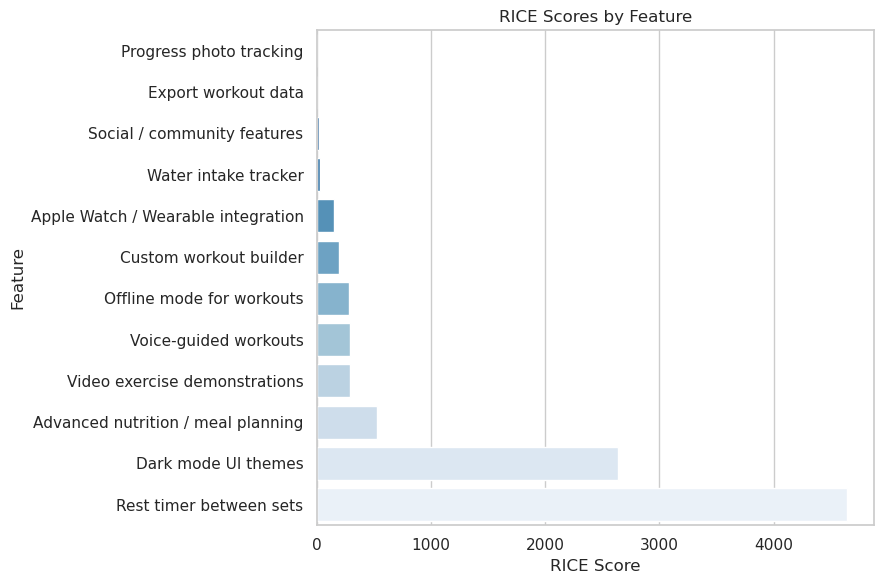

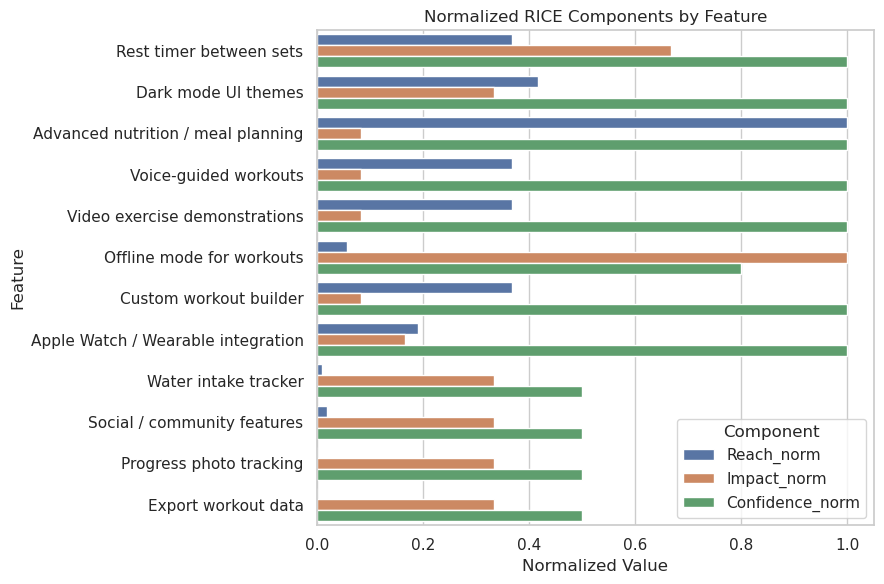

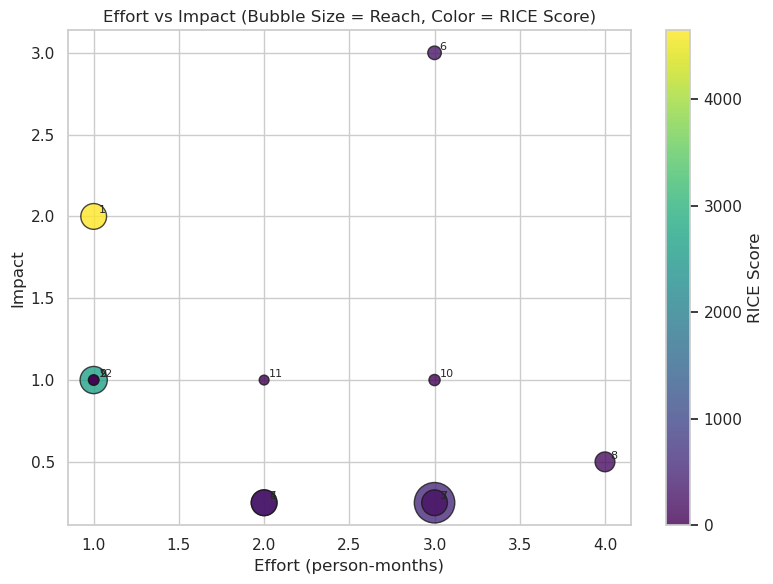

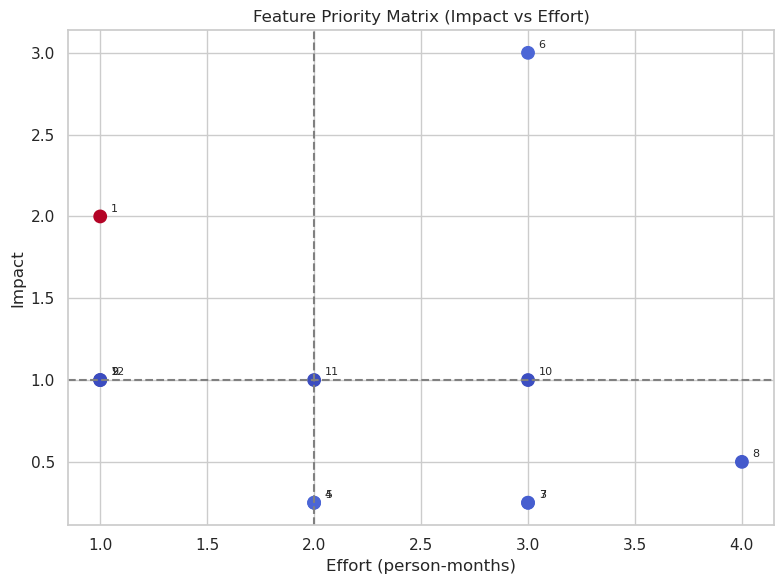

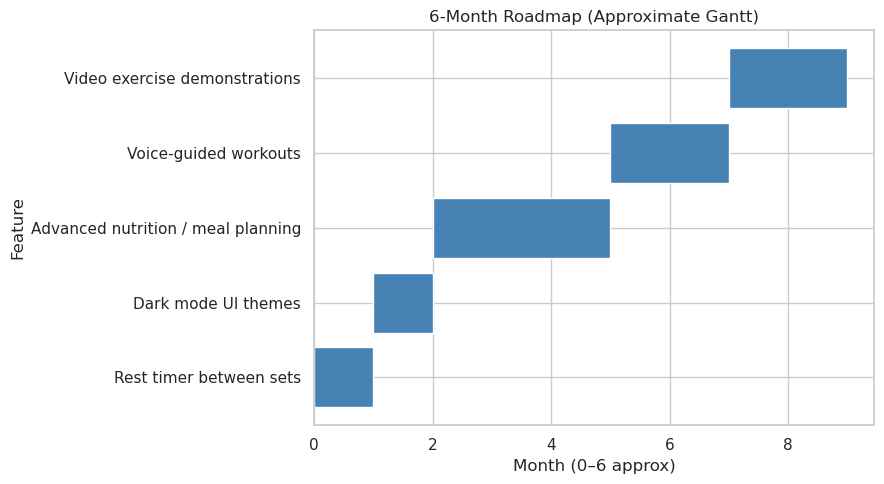

Saved all M3 figures in ./figures_M3


In [10]:
# STEP 9: VISUALIZATIONS

os.makedirs("figures_M3", exist_ok=True)

# 1. RICE Scores – horizontal bar chart
plt.figure(figsize=(9, 6))
sns.barplot(
    data=feat_df.sort_values("RICE_Score", ascending=True),
    x="RICE_Score",
    y="Feature",
    palette="Blues_r"
)
plt.title("RICE Scores by Feature")
plt.xlabel("RICE Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures_M3/RICE_Scores_by_Feature.png", dpi=300)
plt.show()
plt.close()

# 2. RICE Components – stacked bar Reach * Impact * Confidence (use scaled values)
comp_df = feat_df.copy()
comp_df["Reach_norm"] = comp_df["Reach_per_quarter"] / comp_df["Reach_per_quarter"].max()
comp_df["Impact_norm"] = comp_df["Impact"] / 3.0  # max 3
comp_df["Confidence_norm"] = comp_df["Confidence"]  # already 0.5–1

comp_df_melt = comp_df.melt(
    id_vars=["Feature", "Rank"],
    value_vars=["Reach_norm", "Impact_norm", "Confidence_norm"],
    var_name="Component",
    value_name="Value"
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=comp_df_melt.sort_values("Rank"),
    x="Value",
    y="Feature",
    hue="Component"
)
plt.title("Normalized RICE Components by Feature")
plt.xlabel("Normalized Value")
plt.ylabel("Feature")
plt.legend(title="Component")
plt.tight_layout()
plt.savefig("figures_M3/RICE_Components_Stacked.png", dpi=300)
plt.show()
plt.close()

# 3. Effort vs Impact scatter plot (size = Reach, color = RICE)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    feat_df["Effort_person_months"],
    feat_df["Impact"],
    s=feat_df["Reach_per_quarter"] / feat_df["Reach_per_quarter"].max() * 800 + 50,
    c=feat_df["RICE_Score"],
    cmap="viridis",
    alpha=0.8,
    edgecolor="k"
)
for _, row in feat_df.iterrows():
    plt.text(row["Effort_person_months"] + 0.03, row["Impact"] + 0.02,
             str(int(row["Rank"])), fontsize=8)

plt.colorbar(scatter, label="RICE Score")
plt.title("Effort vs Impact (Bubble Size = Reach, Color = RICE Score)")
plt.xlabel("Effort (person-months)")
plt.ylabel("Impact")
plt.tight_layout()
plt.savefig("figures_M3/Effort_vs_Impact_Bubble.png", dpi=300)
plt.show()
plt.close()

# 4. Feature Priority Matrix – Impact vs Effort quadrants
plt.figure(figsize=(8, 6))
plt.scatter(
    feat_df["Effort_person_months"],
    feat_df["Impact"],
    c=feat_df["RICE_Score"],
    cmap="coolwarm",
    s=80
)
for _, row in feat_df.iterrows():
    plt.text(row["Effort_person_months"] + 0.05, row["Impact"] + 0.03,
             str(int(row["Rank"])), fontsize=8)

# Draw median lines for quadrants
effort_med = feat_df["Effort_person_months"].median()
impact_med = feat_df["Impact"].median()
plt.axvline(effort_med, color="gray", linestyle="--")
plt.axhline(impact_med, color="gray", linestyle="--")

plt.title("Feature Priority Matrix (Impact vs Effort)")
plt.xlabel("Effort (person-months)")
plt.ylabel("Impact")
plt.tight_layout()
plt.savefig("figures_M3/Feature_Priority_Matrix.png", dpi=300)
plt.show()
plt.close()

# 5. Simple Roadmap Timeline – Gantt style (approx)
# We map rank order into quarters based on cumulative effort.
roadmap_plot = roadmap.copy()
roadmap_plot["Start_Month"] = 0.0
roadmap_plot["End_Month"] = 0.0

current_month = 0.0
for idx, row in roadmap_plot.sort_values("Rank").iterrows():
    roadmap_plot.loc[idx, "Start_Month"] = current_month
    current_month += row["Effort_person_months"]
    roadmap_plot.loc[idx, "End_Month"] = current_month

plt.figure(figsize=(9, 5))
for i, row in roadmap_plot.iterrows():
    plt.barh(
        y=row["Feature"],
        width=row["End_Month"] - row["Start_Month"],
        left=row["Start_Month"],
        color="steelblue"
    )

plt.xlabel("Month (0–6 approx)")
plt.ylabel("Feature")
plt.title("6-Month Roadmap (Approximate Gantt)")
plt.tight_layout()
plt.savefig("figures_M3/Roadmap_Gantt.png", dpi=300)
plt.show()
plt.close()

print("Saved all M3 figures in ./figures_M3")


In [11]:
# STEP 10: EXPORT TABLES FOR M3 REPORT

os.makedirs("outputs_M3", exist_ok=True)

feat_df.to_csv("outputs_M3/M3_RICE_Full_Table.csv", index=False)
top5.to_csv("outputs_M3/M3_RICE_Top5.csv", index=False)
roadmap.to_csv("outputs_M3/M3_Roadmap_Features.csv", index=False)

print("Saved RICE tables in ./outputs_M3")


Saved RICE tables in ./outputs_M3
